In [1]:
import argparse
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_excel("Concrete_Data.xls")

X = df.iloc[:, :-1]   # all columns except the last one
y = df.iloc[:, -1]    # the last column (strength)


def categorize_strength(value):
    if value < 25.01:
        return 0  # low
    elif value < 55.02:
        return 1  # medium
    else:
        return 2  # high

y_classes = np.array([categorize_strength(val) for val in y])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_classes, test_size=0.2, random_state=42, stratify=y_classes
)

scaler = StandardScaler()
X_train_scaled_withoutCV = scaler.fit_transform(X_train)
X_test_scaled_withoutCV = scaler.transform(X_test)

# 1. Baseline Model

The baseline will be a model which compute the largest class on the training data, and predict everything in the
test-data as belonging to that class (corresponding to the optimal prediction by a logistic
regression model with a bias term and no features

In [3]:
num_low = np.sum(y_classes == 0)
num_medium = np.sum(y_classes == 1)
num_high = np.sum(y_classes == 2)

print(f"Class distribution:\n Low: {num_low}\n Medium: {num_medium}\n High: {num_high}")

Class distribution:
 Low: 295
 Medium: 588
 High: 147


In [4]:
# sicne the medium class has the most samples, the baseline model will predict this class everytime 

from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_scaled_withoutCV, y_train)
y_pred_base = baseline.predict(X_test_scaled_withoutCV)

print(confusion_matrix(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))   

[[  0  59   0]
 [  0 118   0]
 [  0  29   0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        59
           1       0.57      1.00      0.73       118
           2       0.00      0.00      0.00        29

    accuracy                           0.57       206
   macro avg       0.19      0.33      0.24       206
weighted avg       0.33      0.57      0.42       206



/Users/theresabartels/miniforge3/envs/dtu02452/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/theresabartels/miniforge3/envs/dtu02452/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/theresabartels/miniforge3/envs/dtu02452/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [5]:
print(y_pred_base)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


# 2. ANN

In [6]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(hidden_layer_sizes=(64, 32, 16), 
                      activation='relu', solver='adam',
                      #learning_rate='adaptive',
                      #learning_rate_init=0.005,
                      max_iter=3000,
                      random_state=42)


model_mlp.fit(X_train_scaled_withoutCV, y_train)
predictions_ann = model_mlp.predict(X_test_scaled_withoutCV)

test with normal train/test split

In [7]:
print(confusion_matrix(y_test, predictions_ann))
print(classification_report(y_test, predictions_ann))   

[[ 51   8   0]
 [  8 108   2]
 [  0   4  25]]
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        59
           1       0.90      0.92      0.91       118
           2       0.93      0.86      0.89        29

    accuracy                           0.89       206
   macro avg       0.90      0.88      0.89       206
weighted avg       0.89      0.89      0.89       206



two level cross validation: 

In [9]:
print(type(y))

<class 'pandas.core.series.Series'>


We stored the results in a df, so there is no need to perform the two-fold CV everytime 

In [38]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import itertools

results_10k_max4layers = []
predictions = []
outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=10, shuffle=True, random_state=42)

# logistic regression model
logreg = LogisticRegression(max_iter=500)
logreg_params = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

#grid search: parameters than can be chosen
neurons = [16, 32, 64]
max_layers = 3
hidden_layer_sizes = []

# Alle Kombinationen von 1 bis max_layers generieren
for num_layers in range(1, max_layers + 1):
    hidden_layer_sizes += list(itertools.product(neurons, repeat=num_layers))

print("Generated hidden layer for MLP:", hidden_layer_sizes)

mlp_params = {
    'hidden_layer_sizes': hidden_layer_sizes,
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],  
    'learning_rate_init': [0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}


for fold_idx, (train_idx, test_idx)in enumerate(outer_cv.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_classes[train_idx], y_classes[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Baseline
    baseline.fit(X_train_scaled, y_train)
    y_pred_base = baseline.predict(X_test_scaled)
    err_base = 1 - accuracy_score(y_test, y_pred_base)

    # logistic regression
    grid_logreg = GridSearchCV(logreg, logreg_params, cv=inner_cv, n_jobs=-1)
    grid_logreg.fit(X_train_scaled, y_train)
    best_logreg_params = grid_logreg.best_params_

    best_logreg = LogisticRegression(max_iter=500, C=best_logreg_params['C'])
    best_logreg.fit(X_train_scaled, y_train)
    y_pred_logreg = best_logreg.predict(X_test_scaled)
    err_logreg = 1 - accuracy_score(y_test, y_pred_logreg)


    # MLP
    grid_mlp = GridSearchCV(model_mlp, mlp_params, cv=inner_cv, n_jobs=-1)
    grid_mlp.fit(X_train_scaled, y_train)
    best_mlp_params = grid_mlp.best_params_
    
    #use best paramters for whole lopp
    best_mlp_model = MLPClassifier(
        hidden_layer_sizes=best_mlp_params['hidden_layer_sizes'],
        alpha=best_mlp_params['alpha'],
        activation=best_mlp_params['activation'],
        learning_rate=best_mlp_params['learning_rate'],
        learning_rate_init=best_mlp_params['learning_rate_init'],
        max_iter=500
    )

    best_mlp_model.fit(X_train_scaled, y_train)
    y_pred_mlp = best_mlp_model.predict(X_test_scaled)
    err_mlp = 1 - accuracy_score(y_test, y_pred_mlp)

    # results
    results_10k_max4layers.append({
        'Fold': fold_idx,
        'Baseline Error': err_base,
        'LogReg Error': err_logreg,
        'LogReg Params': grid_logreg.best_params_,
        'MLP Error': err_mlp,
        'MLP Params': grid_mlp.best_params_,
    })

    predictions.append({
        'y_true': y_test,
        "y_pred_base": y_pred_base,
        'y_pred_logreg': y_pred_logreg,
        'y_pred_mlp': y_pred_mlp
    })



Generated hidden layer for MLP: [(16,), (32,), (64,), (16, 16), (16, 32), (16, 64), (32, 16), (32, 32), (32, 64), (64, 16), (64, 32), (64, 64), (16, 16, 16), (16, 16, 32), (16, 16, 64), (16, 32, 16), (16, 32, 32), (16, 32, 64), (16, 64, 16), (16, 64, 32), (16, 64, 64), (32, 16, 16), (32, 16, 32), (32, 16, 64), (32, 32, 16), (32, 32, 32), (32, 32, 64), (32, 64, 16), (32, 64, 32), (32, 64, 64), (64, 16, 16), (64, 16, 32), (64, 16, 64), (64, 32, 16), (64, 32, 32), (64, 32, 64), (64, 64, 16), (64, 64, 32), (64, 64, 64)]


/Users/theresabartels/miniforge3/envs/dtu02452/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/theresabartels/miniforge3/envs/dtu02452/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/theresabartels/miniforge3/envs/dtu02452/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/theresabartels/miniforge3/envs/dtu02452/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached 

Task 3: table for every fold

In [8]:
'''
results_df = pd.DataFrame(results)
mlp_params_df = pd.DataFrame(results_df['MLP Params'].tolist())
results_df = pd.concat([results_df, mlp_params_df], axis=1)


logreg_params_df = pd.DataFrame(results_df['LogReg Params'].tolist())
results_df = pd.concat([results_df, logreg_params_df], axis=1)

results_df = results_df[['Fold', 'hidden_layer_sizes', 'alpha', 'MLP Error', 'C', 'LogReg Error', 'Baseline Error']]
results_df.rename(columns={
    'hidden_layer_sizes':'h*', 
    'alpha':'λ*',
    'C':'C*'
}, inplace=True)

results_df.to_csv("results_classification_twofoldCV.csv", index=False)  
'''
results_df = pd.read_csv("results_classification_twofoldCV.csv")
print(results_df)

   Fold         h*      λ*  MLP Error   C*  LogReg Error  Baseline Error
0     1      (64,)  0.0100   0.131068  100      0.189320        0.402913
1     2   (64, 32)  0.0001   0.121359    1      0.218447        0.504854
2     3   (64, 32)  0.0100   0.155340   10      0.203883        0.412621
3     4  (128, 64)  0.0100   0.160194   10      0.223301        0.432039
4     5  (128, 64)  0.0010   0.145631   10      0.203883        0.393204


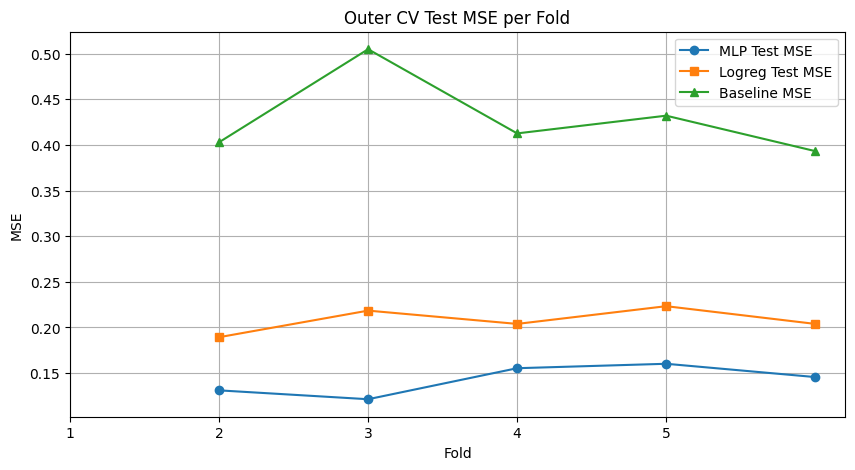

In [ ]:
folds = results_df['Fold'].values
mlp_mse = results_df['MLP Error'].values
baseline_mse = results_df['Baseline Error'].values
logreg_mse = results_df['LogReg Error'].values

plt.figure(figsize=(10,5))
plt.plot(folds, mlp_mse, marker='o', label='MLP Test MSE')
plt.plot(folds, logreg_mse, marker='s', label='Logreg Test MSE')
plt.plot(folds, baseline_mse, marker='^', label='Baseline MSE')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('Outer CV Test MSE per Fold')
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()


task4: final parameters to calculate error 

In [13]:
#fpr MLP
mlp_params_df = results_df[['h*', 'λ*']]
most_common_mlp = mlp_params_df.value_counts().idxmax()
print("Most frequent MLP configuration:", most_common_mlp)


#for logistic regression
logreg_params = results_df['C*']
most_common_logreg = logreg_params.mode()[0]
print("Most frequent LogReg C:", most_common_logreg)


Most frequent MLP configuration: ('(128, 64)', np.float64(0.001))
Most frequent LogReg C: 10


In [14]:
numeric_results = results_df[['Baseline Error', 'LogReg Error', 'MLP Error']].copy()

# Berechne Mean ± SD
summary = numeric_results.agg(['mean', 'std'])
summary_row = summary.apply(lambda x: f"{x['mean']:.3f} ± {x['std']:.3f}")
print(summary_row)

Baseline Error    0.429 ± 0.045
LogReg Error      0.208 ± 0.013
MLP Error         0.143 ± 0.016
dtype: object


Mc Nemar test: 

In [15]:
y_true_all = np.concatenate([r['y_true'] for r in predictions])
y_pred_baseline = np.concatenate([r['y_pred_base'] for r in predictions])
y_pred_logreg = np.concatenate([r['y_pred_logreg'] for r in predictions])
y_pred_mlp = np.concatenate([r['y_pred_mlp'] for r in predictions])

# Try for 10k 2 fold cross validation

   Fold            h*      λ*  MLP Error   C*  LogReg Error  Baseline Error
0     1  (16, 16, 64)  0.0001   0.116505  100      0.184466        0.417476
1     2  (16, 64, 32)  0.0010   0.067961   10      0.223301        0.388350
2     3  (16, 64, 16)  0.0010   0.145631    1      0.213592        0.504854
3     4  (16, 64, 32)  0.0100   0.116505   10      0.165049        0.504854
4     5  (32, 32, 16)  0.0001   0.155340  100      0.213592        0.407767
5     6      (16, 64)  0.0001   0.087379    1      0.135922        0.417476
6     7  (32, 16, 16)  0.0100   0.135922  100      0.194175        0.456311
7     8      (32, 16)  0.0001   0.116505    1      0.233010        0.407767
8     9         (32,)  0.0100   0.135922  100      0.194175        0.398058
9    10      (32, 32)  0.0010   0.116505  100      0.242718        0.388350


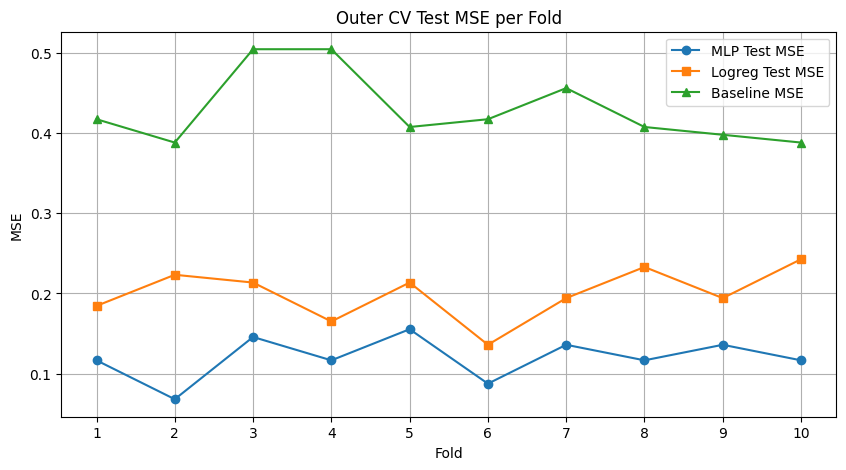

In [40]:

results_10k = pd.DataFrame(results_10k_max4layers)
mlp_params_df = pd.DataFrame(results_10k['MLP Params'].tolist())
results_10k = pd.concat([results_10k, mlp_params_df], axis=1)


logreg_params_df = pd.DataFrame(results_10k['LogReg Params'].tolist())
results_10k = pd.concat([results_10k, logreg_params_df], axis=1)

results_10k = results_10k[['Fold', 'hidden_layer_sizes', 'alpha', 'MLP Error', 'C', 'LogReg Error', 'Baseline Error']]
results_10k.rename(columns={
    'hidden_layer_sizes':'h*', 
    'alpha':'λ*',
    'C':'C*'
}, inplace=True)

results_10k.to_csv("results_classification_twofoldCV_max4layers.csv", index=False)  


results_10k = pd.read_csv("results_classification_twofoldCV_max4layers.csv")
print(results_10k)

folds = results_10k['Fold'].values
mlp_mse = results_10k['MLP Error'].values
baseline_mse = results_10k['Baseline Error'].values
logreg_mse = results_10k['LogReg Error'].values

plt.figure(figsize=(10,5))
plt.plot(folds, mlp_mse, marker='o', label='MLP Test MSE')
plt.plot(folds, logreg_mse, marker='s', label='Logreg Test MSE')
plt.plot(folds, baseline_mse, marker='^', label='Baseline MSE')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('Outer CV Test MSE per Fold')
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()


In [47]:
#fpr MLP
mlp_params_df = results_10k[['h*', 'λ*']]
most_common_mlp = mlp_params_df.value_counts().idxmax()
print("Most frequent MLP configuration:", most_common_mlp)


#for logistic regression
logreg_params = results_10k['C*']
most_common_logreg = logreg_params.mode()[0]
print("Most frequent LogReg C:", most_common_logreg)

Most frequent MLP configuration: ('(16, 16, 64)', np.float64(0.0001))
Most frequent LogReg C: 100


In [48]:
numeric_results = results_10k[['Baseline Error', 'LogReg Error', 'MLP Error']].copy()

# Berechne Mean ± SD
summary = numeric_results.agg(['mean', 'std'])
summary_row = summary.apply(lambda x: f"{x['mean']:.3f} ± {x['std']:.3f}")
print(summary_row)

Baseline Error    0.429 ± 0.044
LogReg Error      0.200 ± 0.032
MLP Error         0.119 ± 0.026
dtype: object


In [49]:
predictions10= predictions.copy()

In [50]:
y_true_all = np.concatenate([r['y_true'] for r in predictions10])
y_pred_baseline = np.concatenate([r['y_pred_base'] for r in predictions10])
y_pred_logreg = np.concatenate([r['y_pred_logreg'] for r in predictions10])
y_pred_mlp = np.concatenate([r['y_pred_mlp'] for r in predictions10])

In [51]:
import sys
#!{sys.executable} -m pip install statsmodels

from statsmodels.stats.contingency_tables import mcnemar

# Discordant pairs
def mcnemar_test(y_true, y_pred_model1, y_pred_model2):
    n12 = np.sum((y_pred_model1 == y_true) & (y_pred_model2 != y_true))
    n21 = np.sum((y_pred_model1 != y_true) & (y_pred_model2 == y_true))

    table = [[0, n12],
            [n21, 0]]

    result = mcnemar(table, exact=True)

    print(f"n12 = {n12}, n21 = {n21}")
    print(f"McNemar statistic = {result.statistic}, p-value = {result.pvalue}")

print("Baseline vs Logistic Regression:")
mcnemar_test(y_true_all, y_pred_baseline, y_pred_logreg)

print("\nBaseline vs MLP:")
mcnemar_test(y_true_all, y_pred_baseline, y_pred_mlp)

print("MLP vs Logistic Regression:")
mcnemar_test(y_true_all, y_pred_mlp, y_pred_logreg)


Baseline vs Logistic Regression:
n12 = 95, n21 = 331
McNemar statistic = 95.0, p-value = 1.1371851450863325e-31

Baseline vs MLP:
n12 = 55, n21 = 374
McNemar statistic = 55.0, p-value = 2.1771143594866126e-59
MLP vs Logistic Regression:
n12 = 125, n21 = 42
McNemar statistic = 42.0, p-value = 9.048109104935016e-11


task 5: train regression model: 

In [52]:
from sklearn.linear_model import LogisticRegression

# Split data in training and test tests
X_train, X_test, y_train, y_test = train_test_split(
    X, y_classes, test_size=0.2, random_state=42, stratify=y_classes
)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

# Implement linear regression fitting the training data
linreg = LogisticRegression() # Model initialized with no learn coefficients yet
linreg.fit(X_train_std, y_train) # Model is being trained

w = linreg.coef_
w0 = linreg.intercept_

print("Optimal Coefficients (w*):", w)
print("Intercept (w0):", w0)
print("\nMatrix equation: ŷ = Xw + w0")

equation = "ŷ = {:.3f}".format(w0)
for coef, name in zip(w, X.columns):
    equation += " + ({:.3f} × {})".format(coef, name)

print("\nLearned linear regression equation:\n", equation)

# Prediction values from the test data
y_pred = linreg.predict(X_test_std)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Optimal Coefficients (w*): [[-2.23449630e+00 -1.41536930e+00 -6.92835335e-01  6.20382402e-01
  -4.68858469e-01 -4.12011575e-02 -4.44404002e-02 -3.87311076e+00]
 [ 7.64073108e-02 -4.71864988e-02 -1.81252047e-01  3.14735408e-01
   3.26017254e-01 -3.02392416e-02  2.02066057e-03  1.48945728e+00]
 [ 2.15808898e+00  1.46255580e+00  8.74087382e-01 -9.35117810e-01
   1.42841214e-01  7.14403991e-02  4.24197397e-02  2.38365348e+00]]
Intercept (w0): [-1.16416227  2.14894726 -0.98478499]

Matrix equation: ŷ = Xw + w0


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_classes, test_size=0.2, random_state=42, stratify=y_classes
)

# Standardization
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, C = 100)
logreg.fit(X_train_std, y_train)

# Coefficients
w = logreg.coef_
w0 = logreg.intercept_

print("Optimal Coefficients (w*):", w)
print("Intercept (w0):", w0)

# Equation
equation = f"ŷ = {w0[0]:.3f}"
for coef, name in zip(w[0], X.columns):
    equation += f" + ({coef:.3f} × {name})"
print("\nLearned logistic regression equation:\n", equation)

# Predictions
y_pred = logreg.predict(X_test_std)

# Accuracy and classification report
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Optimal Coefficients (w*): [[-3.03210991 -2.05105669 -1.21278675  0.48669691 -0.46505803 -0.36819712
  -0.43150651 -5.31670698]
 [ 0.17678238 -0.01501319 -0.19239023  0.35397694  0.35077079 -0.00775461
   0.0415301   2.12764248]
 [ 2.85532753  2.06606988  1.40517697 -0.84067385  0.11428724  0.37595173
   0.38997642  3.1890645 ]]
Intercept (w0): [-1.73924821  2.61227025 -0.87302205]

Learned logistic regression equation:
 ŷ = -1.739 + (-3.032 × Cement (component 1)(kg in a m^3 mixture)) + (-2.051 × Blast Furnace Slag (component 2)(kg in a m^3 mixture)) + (-1.213 × Fly Ash (component 3)(kg in a m^3 mixture)) + (0.487 × Water  (component 4)(kg in a m^3 mixture)) + (-0.465 × Superplasticizer (component 5)(kg in a m^3 mixture)) + (-0.368 × Coarse Aggregate  (component 6)(kg in a m^3 mixture)) + (-0.432 × Fine Aggregate (component 7)(kg in a m^3 mixture)) + (-5.317 × Age (day))
Accuracy: 0.8155339805825242

Confusion Matrix:
 [[ 47  12   0]
 [  8 101   9]
 [  0   9  20]]

Classification Repo